In [1]:
!pip install networkx numpy pandas matplotlib

In [2]:
import networkx as nx
import numpy as np
import random
import pandas as pd

Load Network Dataset

In [3]:
# Example graph
G = nx.karate_club_graph()

# Example node attributes
for node in G.nodes():
    G.nodes[node]['attr'] = random.randint(0,2)

Attribute Similarity Function (SA)

In [4]:
def attribute_similarity(G, communities):

    num = 0
    den = 0

    for c in communities:
        nodes = list(c)
        r = len(nodes)

        if r < 2:
            continue

        den += r*(r-1)

        for i in range(r):
            for j in range(i+1,r):

                a = G.nodes[nodes[i]]['attr']
                b = G.nodes[nodes[j]]['attr']

                if a == b:
                    num += 2

    if den == 0:
        return 0

    return num/den

Modified Modularity (EQOV)

In [5]:
def EQOV(G, communities):

    m = G.number_of_edges()
    score = 0

    membership = {}

    for c in communities:
        for node in c:
            membership[node] = membership.get(node,0)+1

    for c in communities:
        nodes = list(c)

        for i in nodes:
            for j in nodes:

                Aij = 1 if G.has_edge(i,j) else 0
                di = G.degree(i)
                dj = G.degree(j)

                Oi = membership[i]
                Oj = membership[j]

                score += (Aij - (di*dj)/(2*m))/(Oi*Oj)

    return score/(2*m)

Chromosome Representation

In [6]:
def initialize_population(G, pop_size):

    nodes = list(G.nodes())
    n = len(nodes)

    population = []

    for _ in range(pop_size):

        chrom = np.random.randint(0,5,n)   # random communities
        population.append(chrom)

    return population

Decode Chromosome → Communities

In [7]:
def decode(chrom):

    communities = {}

    for i,c in enumerate(chrom):

        communities.setdefault(c,set()).add(i)

    return list(communities.values())

Fitness Evaluation

In [8]:
def evaluate(G, chrom):

    communities = decode(chrom)

    f1 = EQOV(G, communities)
    f2 = attribute_similarity(G, communities)

    return f1, f2

Crossover Operator

In [9]:
def crossover(p1, p2):

    n = len(p1)
    point = random.randint(1,n-1)

    c1 = np.concatenate((p1[:point],p2[point:]))
    c2 = np.concatenate((p2[:point],p1[point:]))

    return c1,c2

Mutation Operator

In [10]:
def mutation(chrom, rate=0.1):

    for i in range(len(chrom)):

        if random.random() < rate:
            chrom[i] = random.randint(0,5)

    return chrom

Evolutionary Algorithm (MOEA-SAOV)

In [11]:
def MOEA_SAOV(G, pop_size=50, generations=50):

    population = initialize_population(G,pop_size)

    for gen in range(generations):

        new_population = []

        while len(new_population) < pop_size:

            p1,p2 = random.sample(population,2)

            c1,c2 = crossover(p1,p2)

            c1 = mutation(c1)
            c2 = mutation(c2)

            new_population.append(c1)
            new_population.append(c2)

        population = new_population

    results = []

    for chrom in population:

        f1,f2 = evaluate(G,chrom)
        results.append((chrom,f1,f2))

    return results

Run Algorithm

In [12]:
results = MOEA_SAOV(G)

for r in results[:5]:
    print("EQOV:",r[1],"SA:",r[2])

EQOV: -0.06426692965154501 SA: 0.24691358024691357
EQOV: -0.02523011176857327 SA: 0.38392857142857145
EQOV: -0.048076923076922996 SA: 0.345679012345679
EQOV: -0.012163050624589083 SA: 0.3018867924528302
EQOV: 0.024490466798159177 SA: 0.29069767441860467


Get Best Community Structure

In [13]:
best = max(results, key=lambda x: x[1]+x[2])

communities = decode(best[0])

print("Detected Communities:")
print(communities)

Detected Communities:
[{0, 4, 5, 6, 8, 18, 21}, {32, 1, 7, 16, 19, 24}, {33, 2, 13, 14, 26, 28, 29}, {11, 3, 12}, {9, 17, 20, 22, 23}, {10, 15, 25, 27, 30, 31}]


Visualize Communities

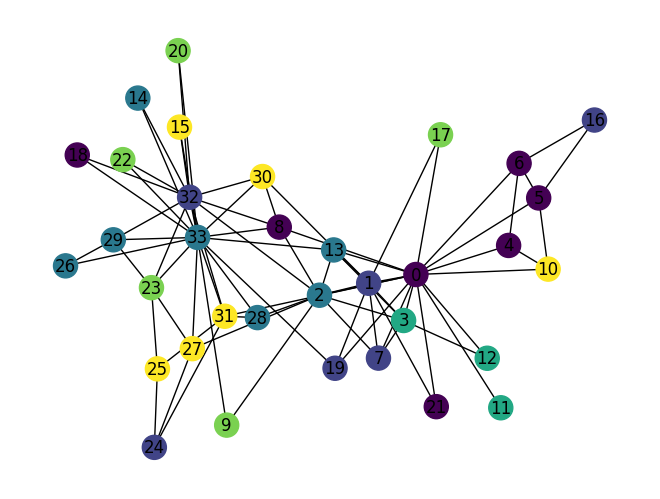

In [14]:
import matplotlib.pyplot as plt

color_map = {}

for i,c in enumerate(communities):
    for node in c:
        color_map[node]=i

colors=[color_map[n] for n in G.nodes()]

nx.draw(G,node_color=colors,with_labels=True)
plt.show()